# aDBS sensing channel + raw LFP viewer (single patient)

1. Run the **cohort** cell → prints all patient IDs in the JSON directory.
2. Set **`PATIENT`** in the next cell (only manual step).
3. Remaining cells auto-detect aDBS sensing bipolars from setup/baseline exports, load matching raw clips, and open the scrollable **bilateral** viewer (Left + Right stacked when both are present).

Does **not** load the full 706-file cohort (avoids the timeline notebook OOM issue).

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    raise ImportError("ipywidgets is required for the clip scroller (pip install ipywidgets)")

plt.style.use('seaborn-v0_8-whitegrid')
DATA_ROOT = Path('/project/hammer_neuromod/RawData/ADAPT_PD/ADAPT-PD_Trial_JSONs')

In [2]:
# All device serials (patient IDs) with at least one JSON export
from collections import Counter

_patient_re = re.compile(r'^([a-zA-Z0-9]+)_')
_file_counts = Counter(
    m.group(1) for p in DATA_ROOT.glob('*.json') if (m := _patient_re.match(p.name))
)
ALL_PATIENTS = sorted(_file_counts)
N_JSON_FILES = sum(_file_counts.values())

print(f'JSON files in directory: {N_JSON_FILES}')
print(f'Patients (unique device serials): {len(ALL_PATIENTS)}\n')
print('Patient IDs:')
for i, pt in enumerate(ALL_PATIENTS):
    print(f'  {i+1:3d}. {pt}  ({_file_counts[pt]} files)')

JSON files in directory: 706
Patients (unique device serials): 85

Patient IDs:
    1. ADF696463  (10 files)
    2. APH797627  (2 files)
    3. ATC028888  (13 files)
    4. BIS265966  (10 files)
    5. BNX420083  (14 files)
    6. BTX569588  (11 files)
    7. CDL324112  (11 files)
    8. DGG102237  (5 files)
    9. DKJ811289  (11 files)
   10. DUH780986  (11 files)
   11. DXM995934  (12 files)
   12. DZR448677  (1 files)
   13. EJQ422786  (11 files)
   14. EPZ003673  (13 files)
   15. FIR525915  (1 files)
   16. FJX898179  (4 files)
   17. FWV214817  (11 files)
   18. FXZ166034  (12 files)
   19. GJT579122  (11 files)
   20. GLY482400  (11 files)
   21. GOS821354  (13 files)
   22. GRM602353  (10 files)
   23. HRL499712  (3 files)
   24. HTA569496  (4 files)
   25. IBJ297420  (11 files)
   26. IFH357629  (2 files)
   27. IKG924665  (6 files)
   28. IMM296499  (10 files)
   29. JHH796828  (11 files)
   30. JQH017870  (2 files)
   31. KLX257257  (12 files)
   32. KOH187986  (1 files)
   

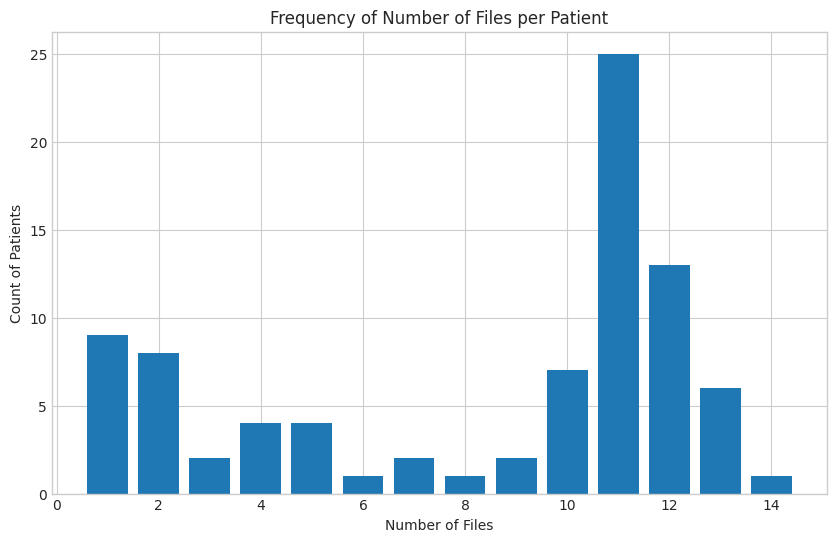

In [3]:
#plot frequency of num files per patient where x-axis is a number of files (x-lims are 0 to 15) and y-axis is count of pts with x number of files

#sort the patients by the number of files
sorted_pts = sorted(ALL_PATIENTS, key=lambda x: _file_counts[x], reverse=True)  

# unique number of files
unique_files = list(set(_file_counts.values()))

#plot x-axis as unique number of files and y-axis as count of pts with x number of files
plt.figure(figsize=(10, 6))
plt.bar(unique_files, [list(_file_counts.values()).count(x) for x in unique_files], align='center')
plt.xlabel('Number of Files')
plt.ylabel('Count of Patients')
plt.title('Frequency of Number of Files per Patient')
plt.show()

In [4]:
# --- only setting you need to change ---
PATIENT = 'BTX569588'
 # device serial from the list above

if PATIENT not in ALL_PATIENTS:
    raise ValueError(f'{PATIENT} not found under {DATA_ROOT}. Pick a serial from ALL_PATIENTS.')
print(f'Selected patient: {PATIENT}')

Selected patient: BTX569588


In [5]:
def _tail(s: str) -> str:
    return s.split('.')[-1] if isinstance(s, str) else s


def parse_file_stem(stem: str) -> dict:
    m = re.match(r'^([a-zA-Z0-9]+)_(.+[AP]M)_(.+)$', stem)
    if not m:
        raise ValueError(f'Unexpected filename stem: {stem}')
    return {
        'patient': m.group(1),
        'timestamp': pd.to_datetime(m.group(2), format=r'%Y-%m-%d_%H_%M_%S%p'),
        'visit': m.group(3),
    }


# SensingElectrodeConfigDef.ZERO_AND_TWO + Left -> ZERO_TWO_LEFT (matches CalibrationTests.Channel)
CONFIG_TO_PAIR = {
    'ZERO_AND_TWO': 'ZERO_TWO',
    'ZERO_AND_THREE': 'ZERO_THREE',
    'ONE_AND_THREE': 'ONE_THREE',
    'ONE_AND_TWO': 'ONE_TWO',
}


def waveform_channel_from_sensing(config: str, hemisphere: str) -> str:
    key = _tail(config)  # e.g. ZERO_AND_TWO from SensingElectrodeConfigDef.ZERO_AND_TWO
    if key not in CONFIG_TO_PAIR:
        raise ValueError(f'Unknown sensing config: {config}')
    return f"{CONFIG_TO_PAIR[key]}_{hemisphere.upper()}"


def _pretty_lead_location(loc: str) -> str:
    """LeadLocationDef.Stn -> 'STN', LeadLocationDef.Gpi -> 'GPi'."""
    tail = (_tail(loc) or '') if loc else ''
    return {'STN': 'STN', 'GPI': 'GPi'}.get(tail.upper(), tail)


def discover_lead_locations(meta: pd.DataFrame) -> dict:
    """Map hemisphere -> stim target (STN / GPi) from LeadConfiguration.

    Prefers *consent* exports; falls back to any file that carries LeadConfiguration.
    """
    ordered = meta.copy()
    ordered['is_consent'] = ordered['visit'].str.contains('consent', case=False, na=False)
    ordered = ordered.sort_values(['is_consent', 'timestamp'], ascending=[False, True])
    for _, row in ordered.iterrows():
        with open(row['path']) as f:
            d = json.load(f)
        lc = d.get('LeadConfiguration') or {}
        for state in ('Final', 'Initial'):
            out = {}
            for lead in lc.get(state) or []:
                hemi = _tail(lead.get('Hemisphere'))
                loc = _pretty_lead_location(lead.get('LeadLocation'))
                if hemi in ('Left', 'Right') and loc:
                    out[hemi] = loc
            if out:
                return out
    return {}


def _visit_priority(visit: str) -> int:
    """Prefer programming session over later eval exports."""
    v = visit.upper()
    if 'ADBS_SETUP' in v:
        return 0
    if 'ADBSEVAL' in v:
        return 1
    if 'CDBS_BASELINE' in v:
        return 2
    return 9


def _adapt_program_score(group: dict) -> int:
    """Score how likely this bank is the real aDBS program (not a spare/unconfigured bank)."""
    score = 0
    if group.get('ActiveGroup'):
        score += 100  # selected on IPG at session end — not the same as 'adapt', but strong signal
    name = (group.get('GroupName') or '').strip().lower()
    if any(tok in name for tok in ('adbs', 'adapt')):
        score += 50
    if name in ('do not use', 'b only', 'b', 'baseline', ''):
        score -= 25
    for sc in (group.get('ProgramSettings') or {}).get('SensingChannel') or []:
        st = str(sc.get('AdaptiveTherapyStatus') or '')
        if 'RUNNING' in st:
            score += 80
        elif 'SUSPENDED' in st:
            score += 40
        elif 'NOT_CONFIGURED' in st:
            score -= 60
        elif 'DISABLED' in st:
            score -= 40
        if sc.get('Mode'):
            score += 25
    return score


def _active_contacts(sc: dict) -> str:
    """Compact stim montage from ElectrodeState, e.g. '-(SenSight_1a, ...) +(Case)'."""
    cath, anod = [], []
    for e in sc.get('ElectrodeState') or []:
        state = str(e.get('ElectrodeStateResult'))
        name = _tail(e.get('Electrode'))
        if 'Negative' in state:
            cath.append(name)
        elif 'Positive' in state:
            anod.append(name)
    parts = []
    if cath:
        parts.append('-(' + ', '.join(cath) + ')')
    if anod:
        parts.append('+(' + ', '.join(anod) + ')')
    return ' '.join(parts)


def _sensing_row(group: dict, sc: dict, hemisphere: str, visit: str, timestamp, path, groups_state: str, score: int) -> dict:
    cfg = sc.get('Channel')
    nested = ((sc.get('SensingSetup') or {}).get('ChannelSignalResult') or {}).get('Channel')
    setup = sc.get('SensingSetup') or {}
    at = sc.get('AdaptiveTherapy') or {}
    return {
        'visit': visit,
        'timestamp': timestamp,
        'file': path.name,
        'groups_state': groups_state,
        'group_id': group.get('GroupId'),
        'group_name': group.get('GroupName'),
        'ipg_bank_selected': group.get('ActiveGroup'),
        'adapt_program_score': score,
        'hemisphere': hemisphere,
        'config': cfg,
        'config_short': _tail(cfg),
        'waveform_channel': waveform_channel_from_sensing(cfg, hemisphere),
        'device_reports_channel': _tail(nested) if nested else None,
        'adaptive_status': sc.get('AdaptiveTherapyStatus'),
        'mode': _tail(sc.get('Mode')),
        'lfp_beta_center_hz': setup.get('FrequencyInHertz'),
        'lfp_averaging_ms': setup.get('AveragingDurationInMilliSeconds'),
        # --- aDBS stim settings (the amplitude 'phases' + LFP thresholds gating them) ---
        'rate_hz': sc.get('RateInHertz'),
        'pulse_width_us': sc.get('PulseWidthInMicroSecond'),
        'active_contacts': _active_contacts(sc),
        'amp_lower_ma': sc.get('LowerLimitInMilliAmps'),
        'amp_upper_ma': sc.get('UpperLimitInMilliAmps'),
        'amp_lower_capture_ma': sc.get('LowerCaptureAmplitudeInMilliAmps'),
        'amp_upper_capture_ma': sc.get('UpperCaptureAmplitudeInMilliAmps'),
        'amp_suspend_ma': sc.get('SuspendAmplitudeInMilliAmps'),
        'lfp_lower_threshold': sc.get('LowerLfpThreshold'),
        'lfp_upper_threshold': sc.get('UpperLfpThreshold'),
        'lfp_measured_lower': sc.get('MeasuredLowerLfp'),
        'lfp_measured_upper': sc.get('MeasuredUpperLfp'),
        'transition_up_ms': sc.get('TransitionUpInMilliSeconds'),
        'transition_down_ms': sc.get('TransitionDownInMilliSeconds'),
        'upper_threshold_onset_ms': at.get('UpperThresholdOnsetInMilliSeconds'),
        'lower_threshold_onset_ms': at.get('LowerThresholdOnsetInMilliSeconds'),
        'startup_delay_ms': at.get('AdaptiveStartupDelayInMilliSeconds'),
        'detection_blanking_ms': at.get('DetectionBlankingDurationInMilliSeconds'),
    }


def discover_adbs_sensing(meta: pd.DataFrame, min_score: int = 20) -> pd.DataFrame:
    """
    Auto-detect aDBS sensing from setup / eval / baseline JSONs.

    ipg_bank_selected (exported as ActiveGroup in raw JSON) means this bank is the one
    selected on the programmer at session end — not whether aDBS is running. We pick the
    highest-scoring adapt program per hemisphere, preferring ADBS_SETUP over later visits.
    """
    visit_re = re.compile(r'ADBS_SETUP|aDBSEval|CDBS_BASELINE', re.I)
    candidates = meta[meta['visit'].str.contains(visit_re)].copy()
    if candidates.empty:
        raise RuntimeError('No ADBS_SETUP / baseline / eval JSON found for this patient')

    candidates['visit_priority'] = candidates['visit'].map(_visit_priority)
    candidates = candidates.sort_values(['visit_priority', 'timestamp'])

    for _, row in candidates.iterrows():
        with open(row['path']) as f:
            d = json.load(f)
        file_rows = []
        for state in ('Final', 'Initial'):
            state_bonus = 10 if state == 'Final' else 0
            for g in d.get('Groups', {}).get(state) or []:
                score = _adapt_program_score(g) + state_bonus
                if score < min_score:
                    continue
                for sc in (g.get('ProgramSettings') or {}).get('SensingChannel') or []:
                    hemi = _tail(sc.get('HemisphereLocation', ''))
                    if hemi not in ('Left', 'Right'):
                        continue
                    file_rows.append(
                        _sensing_row(g, sc, hemi, row['visit'], row['timestamp'], row['path'], state, score)
                    )
        if file_rows:
            df = pd.DataFrame(file_rows)
            best = df.loc[df.groupby('hemisphere')['adapt_program_score'].idxmax()]
            return best.sort_values('hemisphere').reset_index(drop=True)

    raise RuntimeError('No adapt-program SensingChannel found; inspect Groups in ADBS_SETUP JSON')


def summarize_visit_chronic_lfp(meta: pd.DataFrame) -> pd.DataFrame:
    """
    Visit / extend-access files carry cumulative LFPTrendLogs (home beta band power).
    Each reading has only DateTime, LFP, AmplitudeInMilliAmps — no channel tag.
    Channel + beta center frequency come from the active program's SensingChannel on that visit.
    """
    visit_re = re.compile(r'VISIT|EXTEND_ACCESS', re.I)
    visits = meta[meta['visit'].str.contains(visit_re, na=False)].sort_values('timestamp')
    rows = []
    for _, row in visits.iterrows():
        with open(row['path']) as f:
            d = json.load(f)
        lfp_logs = (d.get('DiagnosticData') or {}).get('LFPTrendLogs') or {}
        n_trend = sum(len(entries) for windows in lfp_logs.values() for entries in windows.values())
        las = (d.get('EventSummary') or {}).get('LfpAndAmplitudeSummary') or []
        las_by_hemi = {_tail(x.get('Hemisphere')): x for x in las}
        found_active = False
        groups_used = (d.get('Groups') or {}).get('Final') or []
        groups_state = 'Final'
        if not any(g.get('ActiveGroup') for g in groups_used):
            groups_used = (d.get('Groups') or {}).get('Initial') or []
            groups_state = 'Initial'
        for g in groups_used:
            if not g.get('ActiveGroup'):
                continue
            found_active = True
            gid = _tail(g.get('GroupId'))
            for sc in (g.get('ProgramSettings') or {}).get('SensingChannel') or []:
                hemi = _tail(sc.get('HemisphereLocation'))
                ss = sc.get('SensingSetup') or {}
                summary = las_by_hemi.get(hemi) or {}
                rows.append({
                    'visit': row['visit'],
                    'timestamp': row['timestamp'],
                    'file': row['path'].name,
                    'groups_state': groups_state,
                    'active_group_id': gid,
                    'group_name': g.get('GroupName'),
                    'hemisphere': hemi,
                    'config_short': _tail(sc.get('Channel')),
                    'waveform_channel': waveform_channel_from_sensing(sc.get('Channel'), hemi),
                    'lfp_beta_center_hz': ss.get('FrequencyInHertz'),
                    'lfp_averaging_ms': ss.get('AveragingDurationInMilliSeconds'),
                    'adaptive_status': _tail(sc.get('AdaptiveTherapyStatus')),
                    'n_lfptrend_readings': n_trend,
                    'pct_between_lfp_thresholds': summary.get('BetweenThresholdPercent'),
                    'pct_time_adbs_running': summary.get('TimeAdaptiveRunningPercent'),
                })
        if not found_active and n_trend:
            rows.append({
                'visit': row['visit'], 'timestamp': row['timestamp'], 'file': row['path'].name,
                'groups_state': None, 'active_group_id': None, 'group_name': None,
                'hemisphere': None, 'config_short': None, 'waveform_channel': None,
                'lfp_beta_center_hz': None, 'lfp_averaging_ms': None, 'adaptive_status': None,
                'n_lfptrend_readings': n_trend,
                'pct_between_lfp_thresholds': None, 'pct_time_adbs_running': None,
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(['timestamp', 'hemisphere']).reset_index(drop=True)


def iter_time_domain_clips(data: dict, stream_keys=('CalibrationTests', 'SenseChannelTests', 'BrainSenseTimeDomain')):
    for stream in stream_keys:
        for idx, clip in enumerate(data.get(stream) or []):
            y = clip.get('TimeDomainData')
            if not y:
                continue
            sr = clip.get('SampleRateInHz') or 250
            t0 = pd.to_datetime(clip.get('FirstPacketDateTime'))
            n = len(y)
            t = t0 + pd.to_timedelta(np.arange(n) / sr, unit='s')
            yield {
                'stream': stream,
                'clip_index': idx,
                'channel': clip.get('Channel'),
                'pass': clip.get('Pass'),
                'gain': clip.get('Gain'),
                'sample_rate_hz': sr,
                'n_samples': n,
                'duration_s': n / sr,
                'first_packet': t0,
                'time': t,
                'voltage': np.asarray(y, dtype=float),
            }

In [6]:
patient_files = sorted(DATA_ROOT.glob(f'{PATIENT}_*.json'))
meta = pd.DataFrame([{**parse_file_stem(p.stem), 'path': p, 'size_mb': p.stat().st_size / 1e6} for p in patient_files])
meta = meta.sort_values('timestamp').reset_index(drop=True)
meta

,patient,timestamp,visit,path,size_mb
0,BTX569588,2000-01-01 13:10:14,consent_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,4.302578
1,BTX569588,2000-02-04 12:10:15,LFP_SCREENING_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,0.958725
2,BTX569588,2000-03-24 13:23:19,CDBS_BASELINE_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,1.023454
3,BTX569588,2000-04-21 09:41:56,ADBS_SETUP_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,41.135271
4,BTX569588,2000-05-31 16:03:38,aDBSEvalStart_rand_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,19.262913
5,BTX569588,2000-07-14 14:21:53,VISIT_1_ST,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,5.154363
6,BTX569588,2000-08-16 16:33:56,VISIT_2_DT,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,3.767185
7,BTX569588,2000-10-18 15:02:57,VISIT_3_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,2.646501
8,BTX569588,2000-12-16 13:41:05,VISIT_4_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,5.677467
9,BTX569588,2001-03-16 12:02:14,VISIT_5_NA,/project/hammer_neuromod/RawData/ADAPT_PD/ADAP...,16.116479


In [7]:
# Auto-detect aDBS sensing bipolars (no manual hemisphere / group)
sensing = discover_adbs_sensing(meta)
TARGET_CHANNELS = sensing['waveform_channel'].unique().tolist()
ADAPT_GROUP = _tail(sensing.iloc[0]['group_id'])
LEAD_LOCATIONS = discover_lead_locations(meta)

print(f'Auto-detected aDBS sensing for {PATIENT}')
print('  Stim target (LeadConfiguration.LeadLocation):')
for hemi in ['Left', 'Right']:
    if hemi in LEAD_LOCATIONS:
        print(f'    {hemi}: {LEAD_LOCATIONS[hemi]}')
if not LEAD_LOCATIONS:
    print('    (no LeadConfiguration found in this patient\'s exports)')
print(f'  Source: {sensing.iloc[0]["file"]}  Groups.{sensing.iloc[0]["groups_state"]}  bank {ADAPT_GROUP} ({sensing.iloc[0]["group_name"]})')
print('  Note: ipg_bank_selected=True means that bank was selected on the programmer at session end,')
print('        not necessarily that aDBS was running. adapt_program_score ranks the real aDBS program.')
print('  lfp_beta_center_hz = SensingSetup.FrequencyInHertz (home/chronic beta metric center, not raw EEG).')
display(sensing)

# aDBS stim settings per hemisphere (the amplitude 'phases' + LFP thresholds that gate them)
STIM_COLS = [
    'hemisphere', 'waveform_channel', 'mode', 'rate_hz', 'pulse_width_us', 'active_contacts',
    'amp_lower_ma', 'amp_upper_ma', 'amp_lower_capture_ma', 'amp_upper_capture_ma', 'amp_suspend_ma',
    'lfp_lower_threshold', 'lfp_upper_threshold', 'lfp_measured_lower', 'lfp_measured_upper',
    'transition_up_ms', 'transition_down_ms', 'upper_threshold_onset_ms', 'lower_threshold_onset_ms',
    'startup_delay_ms', 'detection_blanking_ms',
]
stim_settings = sensing[STIM_COLS].set_index('hemisphere')
print('\naDBS stim settings per hemisphere (amplitude phases + LFP thresholds):')
for hemi, r in stim_settings.iterrows():
    print(
        f"  {hemi} {LEAD_LOCATIONS.get(hemi, '')}: {r['waveform_channel']} | {r['mode']} | "
        f"{r['rate_hz']} Hz / {r['pulse_width_us']} us | "
        f"amp {r['amp_lower_ma']}\u2013{r['amp_upper_ma']} mA (suspend {r['amp_suspend_ma']}) | "
        f"LFP thr {r['lfp_lower_threshold']}/{r['lfp_upper_threshold']} | {r['active_contacts']}"
    )
display(stim_settings)
print(f'\nWaveform clip filter: Channel in {TARGET_CHANNELS}')
print('Run the next section for per-visit LFPTrendLogs + beta Hz from visit files.')

Auto-detected aDBS sensing for BTX569588
  Stim target (LeadConfiguration.LeadLocation):
    Left: STN
    Right: STN
  Source: BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA.json  Groups.Final  bank GROUP_B ()
  Note: ipg_bank_selected=True means that bank was selected on the programmer at session end,
        not necessarily that aDBS was running. adapt_program_score ranks the real aDBS program.
  lfp_beta_center_hz = SensingSetup.FrequencyInHertz (home/chronic beta metric center, not raw EEG).


,visit,timestamp,file,groups_state,group_id,group_name,ipg_bank_selected,adapt_program_score,hemisphere,config,...,lfp_lower_threshold,lfp_upper_threshold,lfp_measured_lower,lfp_measured_upper,transition_up_ms,transition_down_ms,upper_threshold_onset_ms,lower_threshold_onset_ms,startup_delay_ms,detection_blanking_ms
0,ADBS_SETUP_NA,2000-04-21 09:41:56,BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA....,Final,GroupIdDef.GROUP_B,,True,150,Left,SensingElectrodeConfigDef.ONE_AND_THREE,...,879,879,718,1797,500,250,200,200,10000,550
1,ADBS_SETUP_NA,2000-04-21 09:41:56,BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA....,Final,GroupIdDef.GROUP_A,,False,115,Right,SensingElectrodeConfigDef.ONE_AND_THREE,...,385,709,478,1402,150000,300000,1200,1200,10000,800



aDBS stim settings per hemisphere (amplitude phases + LFP thresholds):
  Left STN: ONE_THREE_LEFT | SINGLE_THRESHOLD_DIRECT | 130 Hz / 90 us | amp 2.0–3.4 mA (suspend 3.3) | LFP thr 879/879 | -(FourElectrodes_2) +(Case)
  Right STN: ONE_THREE_RIGHT | DUAL_THRESHOLD_DIRECT | 130 Hz / 60 us | amp 2.0–4.3 mA (suspend 4.3) | LFP thr 385/709 | -(FourElectrodes_3) +(Case)


,waveform_channel,mode,rate_hz,pulse_width_us,active_contacts,amp_lower_ma,amp_upper_ma,amp_lower_capture_ma,amp_upper_capture_ma,amp_suspend_ma,lfp_lower_threshold,lfp_upper_threshold,lfp_measured_lower,lfp_measured_upper,transition_up_ms,transition_down_ms,upper_threshold_onset_ms,lower_threshold_onset_ms,startup_delay_ms,detection_blanking_ms
hemisphere,,,,,,,,,,,,,,,,,,,,
Left,ONE_THREE_LEFT,SINGLE_THRESHOLD_DIRECT,130,90,-(FourElectrodes_2) +(Case),2.0,3.4,0,3.6,3.3,879,879,718,1797,500,250,200,200,10000,550
Right,ONE_THREE_RIGHT,DUAL_THRESHOLD_DIRECT,130,60,-(FourElectrodes_3) +(Case),2.0,4.3,1,3.5,4.3,385,709,478,1402,150000,300000,1200,1200,10000,800



Waveform clip filter: Channel in ['ONE_THREE_LEFT', 'ONE_THREE_RIGHT']
Run the next section for per-visit LFPTrendLogs + beta Hz from visit files.


In [8]:
# Cross-check: the detection above is anchored on the ADBS_SETUP/eval program (correct era for the
# in-clinic waveforms). Here we scan EVERY export (consent -> EXTEND_ACCESS) and confirm the adaptive
# sensing channel never silently changes mid-study. A mismatch is flagged rather than hidden.
def audit_sensing_channel_stability(meta: pd.DataFrame) -> pd.DataFrame:
    """Best-scoring adaptive sensing channel per hemisphere, for every patient export."""
    rows = []
    for _, r in meta.sort_values('timestamp').iterrows():
        with open(r['path']) as f:
            d = json.load(f)
        best = {}  # hemisphere -> (score, waveform_channel, adaptive_status)
        groups = d.get('Groups') or {}
        for state in ('Final', 'Initial'):
            bonus = 10 if state == 'Final' else 0
            for g in groups.get(state) or []:
                sgrp = _adapt_program_score(g) + bonus
                for sc in (g.get('ProgramSettings') or {}).get('SensingChannel') or []:
                    hemi = _tail(sc.get('HemisphereLocation') or '')
                    if hemi not in ('Left', 'Right'):
                        continue
                    try:
                        wch = waveform_channel_from_sensing(sc.get('Channel'), hemi)
                    except ValueError:
                        wch = _tail(sc.get('Channel'))
                    if hemi not in best or sgrp > best[hemi][0]:
                        best[hemi] = (sgrp, wch, _tail(sc.get('AdaptiveTherapyStatus') or ''))
        for hemi in ('Left', 'Right'):
            if hemi in best:
                rows.append({
                    'timestamp': r['timestamp'], 'visit': r['visit'], 'hemisphere': hemi,
                    'waveform_channel': best[hemi][1], 'adaptive_status': best[hemi][2],
                })
    return pd.DataFrame(rows)


sensing_timeline = audit_sensing_channel_stability(meta)
setup_channel = dict(zip(sensing['hemisphere'], sensing['waveform_channel']))

stable = True
for hemi in ('Left', 'Right'):
    seen = sorted(
        sensing_timeline.loc[sensing_timeline['hemisphere'] == hemi, 'waveform_channel']
        .dropna().unique()
    )
    if not seen:
        continue
    expected = setup_channel.get(hemi)
    extra = [c for c in seen if c != expected]
    if extra:
        stable = False
        print(f'WARNING: {hemi} sensing channel changed over time: setup={expected}, also seen {extra}')
    else:
        print(f'OK: {hemi} sensing channel stable across all exports ({expected})')
if stable:
    print('\naDBS sensing channel matches the setup-detected channel across every export '
          '(in-clinic + chronic visits).')
else:
    print('\nReview the timeline below: the channel used at home differs from the setup config.')

# One row per export, channel per hemisphere
timeline_wide = (
    sensing_timeline
    .pivot_table(index=['timestamp', 'visit'], columns='hemisphere',
                 values='waveform_channel', aggfunc='first')
    .reset_index()
    .sort_values('timestamp')
)
display(timeline_wide)

OK: Left sensing channel stable across all exports (ONE_THREE_LEFT)
OK: Right sensing channel stable across all exports (ONE_THREE_RIGHT)

aDBS sensing channel matches the setup-detected channel across every export (in-clinic + chronic visits).


hemisphere,timestamp,visit,Left,Right
0,2000-01-01 13:10:14,consent_NA,ONE_THREE_LEFT,NaN
1,2000-02-04 12:10:15,LFP_SCREENING_NA,ONE_THREE_LEFT,NaN
2,2000-03-24 13:23:19,CDBS_BASELINE_NA,ONE_THREE_LEFT,NaN
3,2000-04-21 09:41:56,ADBS_SETUP_NA,ONE_THREE_LEFT,ONE_THREE_RIGHT
4,2000-05-31 16:03:38,aDBSEvalStart_rand_NA,ONE_THREE_LEFT,ONE_THREE_RIGHT
5,2000-07-14 14:21:53,VISIT_1_ST,ONE_THREE_LEFT,ONE_THREE_RIGHT
6,2000-08-16 16:33:56,VISIT_2_DT,ONE_THREE_LEFT,ONE_THREE_RIGHT
7,2000-10-18 15:02:57,VISIT_3_NA,ONE_THREE_LEFT,ONE_THREE_RIGHT
8,2000-12-16 13:41:05,VISIT_4_NA,ONE_THREE_LEFT,ONE_THREE_RIGHT
9,2001-03-16 12:02:14,VISIT_5_NA,ONE_THREE_LEFT,ONE_THREE_RIGHT


## Chronic home LFP on visit files (`LFPTrendLogs`)

Visit exports add **cumulative** `DiagnosticData.LFPTrendLogs` (~every 10 min): each point is **beta band power** (`LFP`), not a raw waveform.

Important:
- Trend rows do **not** include channel or frequency — you infer them from **`Groups.Final` / `Initial`** on the **active** program bank for that visit.
- **`SensingSetup.FrequencyInHertz`** is the programmed **beta band center (Hz)** used for that chronic metric (often ~13–30 Hz band, center e.g. 23.44 Hz). This is what you want for “what frequency is the beta power at?” — not the in-clinic PSD peak.
- **`EventSummary.LfpAndAmplitudeSummary`** gives % time above/between/below thresholds for the active group × hemisphere.

Visit-file chronic LFP summary (12 rows):
  Beta center frequency (SensingSetup.FrequencyInHertz) per hemisphere:
    Left: [np.float64(19.53)] Hz
    Right: [np.float64(19.53)] Hz
  Sensing bipolar → waveform channel:
    Left: ['ONE_THREE_LEFT']
    Right: ['ONE_THREE_RIGHT']

  Raw waveform viewer uses: ['ONE_THREE_LEFT', 'ONE_THREE_RIGHT']
  (should match waveform_channel above when the same bipolar is programmed)



,visit,timestamp,file,groups_state,active_group_id,group_name,hemisphere,config_short,waveform_channel,lfp_beta_center_hz,lfp_averaging_ms,adaptive_status,n_lfptrend_readings,pct_between_lfp_thresholds,pct_time_adbs_running
0,VISIT_1_ST,2000-07-14 14:21:53,BTX569588_2000-07-14_14_21_53PM_VISIT_1_ST.json,Final,GROUP_A,aDBS,Left,ONE_AND_THREE,ONE_THREE_LEFT,19.53,1200,RUNNING,8920,N/A,100
1,VISIT_1_ST,2000-07-14 14:21:53,BTX569588_2000-07-14_14_21_53PM_VISIT_1_ST.json,Final,GROUP_A,aDBS,Right,ONE_AND_THREE,ONE_THREE_RIGHT,19.53,1200,RUNNING,8920,N/A,0
2,VISIT_2_DT,2000-08-16 16:33:56,BTX569588_2000-08-16_16_33_56PM_VISIT_2_DT.json,Final,GROUP_A,aDBS,Left,ONE_AND_THREE,ONE_THREE_LEFT,19.53,1200,RUNNING,13394,N/A,0
3,VISIT_2_DT,2000-08-16 16:33:56,BTX569588_2000-08-16_16_33_56PM_VISIT_2_DT.json,Final,GROUP_A,aDBS,Right,ONE_AND_THREE,ONE_THREE_RIGHT,19.53,1200,RUNNING,13394,46,100
4,VISIT_3_NA,2000-10-18 15:02:57,BTX569588_2000-10-18_15_02_57PM_VISIT_3_NA.json,Final,GROUP_A,aDBS,Left,ONE_AND_THREE,ONE_THREE_LEFT,19.53,1200,RUNNING,17280,48,95
5,VISIT_3_NA,2000-10-18 15:02:57,BTX569588_2000-10-18_15_02_57PM_VISIT_3_NA.json,Final,GROUP_A,aDBS,Right,ONE_AND_THREE,ONE_THREE_RIGHT,19.53,1200,RUNNING,17280,48,95
6,VISIT_4_NA,2000-12-16 13:41:05,BTX569588_2000-12-16_13_41_05PM_VISIT_4_NA.json,Final,GROUP_A,aDBS,Left,ONE_AND_THREE,ONE_THREE_LEFT,19.53,1200,RUNNING,17022,50,100
7,VISIT_4_NA,2000-12-16 13:41:05,BTX569588_2000-12-16_13_41_05PM_VISIT_4_NA.json,Final,GROUP_A,aDBS,Right,ONE_AND_THREE,ONE_THREE_RIGHT,19.53,1200,RUNNING,17022,50,100
8,VISIT_5_NA,2001-03-16 12:02:14,BTX569588_2001-03-16_12_02_14PM_VISIT_5_NA.json,Final,GROUP_A,aDBS,Left,ONE_AND_THREE,ONE_THREE_LEFT,19.53,1200,RUNNING,17280,33,67
9,VISIT_5_NA,2001-03-16 12:02:14,BTX569588_2001-03-16_12_02_14PM_VISIT_5_NA.json,Final,GROUP_A,aDBS,Right,ONE_AND_THREE,ONE_THREE_RIGHT,19.53,1200,RUNNING,17280,33,67


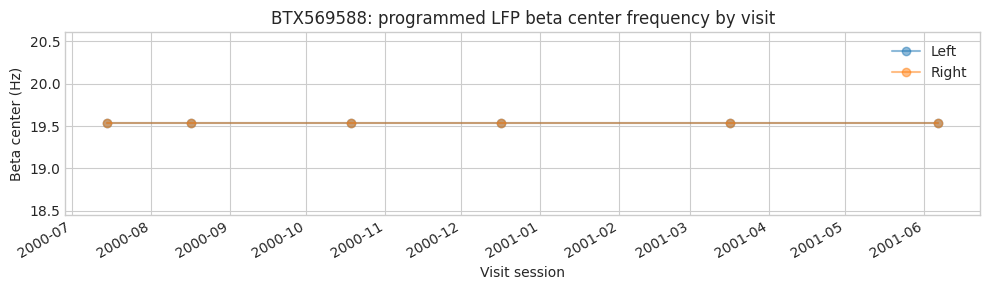

In [9]:
visit_lfp = summarize_visit_chronic_lfp(meta)

if visit_lfp.empty:
    print('No VISIT / EXTEND_ACCESS files for this patient.')
else:
    hz = visit_lfp.groupby('hemisphere')['lfp_beta_center_hz'].unique()
    ch = visit_lfp.groupby('hemisphere')['waveform_channel'].unique()
    print(f'Visit-file chronic LFP summary ({len(visit_lfp)} rows):')
    print('  Beta center frequency (SensingSetup.FrequencyInHertz) per hemisphere:')
    for hemi in ['Left', 'Right']:
        if hemi in hz.index:
            print(f'    {hemi}: {list(hz[hemi])} Hz')
    print('  Sensing bipolar → waveform channel:')
    for hemi in ['Left', 'Right']:
        if hemi in ch.index:
            print(f'    {hemi}: {list(ch[hemi])}')
    print(f'\n  Raw waveform viewer uses: {TARGET_CHANNELS}')
    print('  (should match waveform_channel above when the same bipolar is programmed)\n')
    display(visit_lfp)

    # quick plot: beta center vs visit time (if frequency ever changes)
    freq_plot = (
        visit_lfp.dropna(subset=['lfp_beta_center_hz', 'hemisphere'])
        .drop_duplicates(['timestamp', 'hemisphere'])
    )
    if not freq_plot.empty:
        fig, ax = plt.subplots(figsize=(10, 3))
        for hemi, sub in freq_plot.groupby('hemisphere'):
            ax.plot(sub['timestamp'], sub['lfp_beta_center_hz'], 'o-', label=hemi, alpha=0.5)
        ax.set_ylabel('Beta center (Hz)')
        ax.set_xlabel('Visit session')
        ax.set_title(f'{PATIENT}: programmed LFP beta center frequency by visit')
        ax.legend()
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

In [10]:
# Load only early in-clinic sessions that typically contain calibration / screening waveforms
EARLY_VISIT_RE = re.compile(r'consent|LFP_SCREENING|ADBS_SETUP', re.I)
early = meta[meta['visit'].str.contains(EARLY_VISIT_RE)].copy()
print(f'Loading {len(early)} early session file(s)...')

# False = show every recorded montage (all calibration / sense-channel tests, both sides).
# True  = keep only the auto-detected aDBS sensing channel per hemisphere (TARGET_CHANNELS).
RESTRICT_TO_ADBS_CHANNELS = False

clips = []
catalog = []
for _, row in early.iterrows():
    with open(row['path']) as f:
        d = json.load(f)
    for clip in iter_time_domain_clips(d):
        ch = str(clip['channel'] or '')
        # Channel may carry a trailing test-index suffix (e.g. ZERO_TWO_LEFT_2),
        # so match the hemisphere tag even when a numeric suffix follows it.
        if not re.search(r'_(LEFT|RIGHT)(?:_\d+)?$', ch):
            continue  # need a clear Left/Right montage to place the clip
        if RESTRICT_TO_ADBS_CHANNELS and re.sub(r'_\d+$', '', ch) not in TARGET_CHANNELS:
            continue
        clip['visit'] = row['visit']
        clip['file'] = row['path'].name
        clips.append(clip)
        catalog.append({
            'clip_pos': len(clips) - 1,  # stable index into `clips` (survives sorting)
            'visit': row['visit'],
            'session_timestamp': row['timestamp'],
            'file': row['path'].name,
            **{k: clip[k] for k in [
                'stream', 'clip_index', 'channel', 'pass', 'gain',
                'sample_rate_hz', 'n_samples', 'duration_s', 'first_packet',
            ]},
        })

clip_catalog = pd.DataFrame(catalog).sort_values(['session_timestamp', 'stream', 'clip_index']).reset_index(drop=True)


def hemisphere_from_channel(ch) -> str | None:
    s = str(ch or '')
    if re.search(r'_LEFT(?:_\d+)?$', s):
        return 'Left'
    if re.search(r'_RIGHT(?:_\d+)?$', s):
        return 'Right'
    return None


def hemi_location(hemi: str) -> str:
    """Stim target (STN / GPi) for a hemisphere, '' if unknown."""
    return LEAD_LOCATIONS.get(hemi, '')


def stim_target_label() -> str:
    """Compact bilateral target summary, e.g. 'L-STN / R-STN'."""
    parts = [
        f"{abbr}-{LEAD_LOCATIONS[hemi]}"
        for hemi, abbr in (('Left', 'L'), ('Right', 'R'))
        if hemi in LEAD_LOCATIONS
    ]
    return ' / '.join(parts)


PAIR_COLS = ['visit', 'file', 'stream', 'pass', 'first_packet', 'duration_s']


def _montage_of(channel) -> str:
    """Bipolar montage without the hemisphere suffix, e.g. ZERO_TWO_LEFT_2 -> ZERO_TWO."""
    return re.sub(r'_(LEFT|RIGHT)(?:_\d+)?$', '', str(channel or ''))


def _make_segment(grp: pd.DataFrame) -> dict:
    idx_by_hemi = {}
    for _, row in grp.iterrows():
        hemi = row['hemisphere']
        if hemi and hemi not in idx_by_hemi:  # first clip wins if a side repeats
            idx_by_hemi[hemi] = int(row['clip_pos'])
    base = grp.iloc[0]
    return {
        'visit': base['visit'],
        'session_timestamp': base['session_timestamp'],
        'file': base['file'],
        'stream': base['stream'],
        'pass': base['pass'],
        'first_packet': base['first_packet'],
        'duration_s': base['duration_s'],
        'left_idx': idx_by_hemi.get('Left'),
        'right_idx': idx_by_hemi.get('Right'),
        'channels': {h: clips[i]['channel'] for h, i in idx_by_hemi.items()},
    }


def _segment_sort_key(s: dict):
    chans = s.get('channels') or {}
    montage = '/'.join(sorted({_montage_of(c) for c in chans.values()}))
    return (s['session_timestamp'], s['file'], s['stream'], s['pass'] or '', str(s['first_packet']), montage)


def build_bilateral_segments(catalog: pd.DataFrame, hide_single_hemi_calibration: bool = False) -> list[dict]:
    """Group the Left/Right clips of each recording into bilateral segments.

    A segment = the Left and Right clip of one recording. Within a single timestamped run,
    if a hemisphere has multiple montages (e.g. SenseChannelTests SQC sweeps several bipolars),
    the run is split per montage so no montage is silently dropped. Simple runs (calibration,
    streaming) with one clip per side stay a single segment even when the two sides use
    different montages (as the aDBS streaming pair does: e.g. ONE_THREE_LEFT + ZERO_TWO_RIGHT).
    """
    cat = catalog.assign(
        hemisphere=catalog['channel'].map(hemisphere_from_channel),
        montage=catalog['channel'].map(_montage_of),
    )
    bilateral_patient = {'Left', 'Right'} <= set(cat['hemisphere'].dropna().unique())
    segments = []
    for _, grp in cat.groupby(PAIR_COLS, dropna=False):
        grp = grp[grp['hemisphere'].notna()]
        if grp.empty:
            continue
        n_left = int((grp['hemisphere'] == 'Left').sum())
        n_right = int((grp['hemisphere'] == 'Right').sum())
        if n_left <= 1 and n_right <= 1:
            segments.append(_make_segment(grp))
        else:  # multiple montages per side in one run -> one segment per montage
            for _, sub in grp.groupby('montage', dropna=False):
                segments.append(_make_segment(sub))
    if hide_single_hemi_calibration and bilateral_patient:
        n_before = len(segments)
        segments = [
            s for s in segments
            if not (
                s['stream'] == 'CalibrationTests'
                and (s['left_idx'] is None) != (s['right_idx'] is None)
            )
        ]
        n_hidden = n_before - len(segments)
        if n_hidden:
            print(
                f'Hidden {n_hidden} single-hemisphere CalibrationTests segment(s) '
                '(contralateral aDBS montage not recorded)'
            )
    return sorted(segments, key=_segment_sort_key)


bilateral_segments = build_bilateral_segments(clip_catalog)
n_paired = sum(1 for s in bilateral_segments if s['left_idx'] is not None and s['right_idx'] is not None)
_filter_note = (
    f'aDBS channels {TARGET_CHANNELS}' if RESTRICT_TO_ADBS_CHANNELS
    else 'ALL montages (no channel filter)'
)
print(f'{len(clips)} clip(s) loaded - {_filter_note}')
print(f'{len(bilateral_segments)} segment(s) ({n_paired} with both Left + Right)')
print(f'Stim target: {stim_target_label() or "unknown"}')
clip_catalog.assign(hemisphere=clip_catalog['channel'].map(hemisphere_from_channel))

Loading 3 early session file(s)...
64 clip(s) loaded - ALL montages (no channel filter)
44 segment(s) (20 with both Left + Right)
Stim target: L-STN / R-STN


,clip_pos,visit,session_timestamp,file,stream,clip_index,channel,pass,gain,sample_rate_hz,n_samples,duration_s,first_packet,hemisphere
0,20,consent_NA,2000-01-01 13:10:14,BTX569588_2000-01-01_13_10_14PM_consent_NA.json,BrainSenseTimeDomain,0,ONE_THREE_LEFT,,224,250,29375,117.500,2000-01-01 13:28:57,Left
1,21,consent_NA,2000-01-01 13:10:14,BTX569588_2000-01-01_13_10_14PM_consent_NA.json,BrainSenseTimeDomain,1,ONE_THREE_LEFT,,224,250,100500,402.000,2000-01-01 13:31:14,Left
2,0,consent_NA,2000-01-01 13:10:14,BTX569588_2000-01-01_13_10_14PM_consent_NA.json,CalibrationTests,0,ZERO_TWO_LEFT,ZERO_TWO,224,250,5313,21.252,2000-01-01 13:13:10,Left
3,1,consent_NA,2000-01-01 13:10:14,BTX569588_2000-01-01_13_10_14PM_consent_NA.json,CalibrationTests,1,ZERO_TWO_RIGHT,ZERO_TWO,228,250,5313,21.252,2000-01-01 13:13:10,Right
4,2,consent_NA,2000-01-01 13:10:14,BTX569588_2000-01-01_13_10_14PM_consent_NA.json,CalibrationTests,2,ONE_THREE_LEFT,ONE_THREE,224,250,5313,21.252,2000-01-01 13:13:40,Left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,37,ADBS_SETUP_NA,2000-04-21 09:41:56,BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA....,SenseChannelTests,1,ONE_THREE_LEFT,SQC,228,250,5288,21.152,2000-04-21 09:45:56,Left
60,38,ADBS_SETUP_NA,2000-04-21 09:41:56,BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA....,SenseChannelTests,2,ZERO_TWO_LEFT,SQC,224,250,5288,21.152,2000-04-21 09:45:56,Left
61,39,ADBS_SETUP_NA,2000-04-21 09:41:56,BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA....,SenseChannelTests,3,ZERO_THREE_RIGHT,SQC,224,250,5288,21.152,2000-04-21 09:45:56,Right
62,40,ADBS_SETUP_NA,2000-04-21 09:41:56,BTX569588_2000-04-21_09_41_56AM_ADBS_SETUP_NA....,SenseChannelTests,4,ONE_THREE_RIGHT,SQC,223,250,5288,21.152,2000-04-21 09:45:56,Right


In [13]:
def _max_window_start(clip: dict, window_sec: float) -> float:
    return float(max(0.0, clip['duration_s'] - window_sec))


def _visible_segment(clip: dict, start_sec: float, window_sec: float):
    t = clip['time']
    y = clip['voltage']
    t_start = clip['first_packet'] + pd.Timedelta(seconds=start_sec)
    t_end = t_start + pd.Timedelta(seconds=window_sec)
    mask = (t >= t_start) & (t < t_end)
    return t[mask], y[mask], t_start, t_end


def _segment_clip_list(segment: dict) -> list[tuple[str, dict]]:
    """Left then Right when both exist (single hemisphere if unilateral)."""
    out = []
    for hemi, key in (('Left', 'left_idx'), ('Right', 'right_idx')):
        idx = segment.get(key)
        if idx is not None:
            out.append((hemi, clips[idx]))
    return out


def _max_window_start_segment(segment: dict, window_sec: float) -> float:
    starts = [_max_window_start(c, window_sec) for _, c in _segment_clip_list(segment)]
    return float(min(starts)) if starts else 0.0


def plot_clip_window(clip: dict, start_sec: float, window_sec: float, ax=None, ylim=None, title=None, seconds_axis=False):
    t_vis, y_vis, t_start, t_end = _visible_segment(clip, start_sec, window_sec)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    else:
        fig = ax.figure
    if seconds_axis:
        clip_start = clip['first_packet']
        x_vis = (t_vis - clip_start).total_seconds() if len(t_vis) else t_vis
        x_start = (t_start - clip_start).total_seconds()
        x_end = (t_end - clip_start).total_seconds()
    else:
        x_vis, x_start, x_end = t_vis, t_start, t_end
    if len(t_vis):
        ax.plot(x_vis, y_vis, lw=0.7, color='k')
    ax.set_xlim(x_start, x_end)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.set_ylabel('Amplitude (µV)')  # Percept TimeDomainData is gain-corrected to microvolts
    ax.set_title(title or (
        f"{clip['channel']} | Pass={clip['pass']} | gain={clip['gain']} | "
        f"{start_sec:.2f}–{start_sec + window_sec:.2f}s of {clip['duration_s']:.2f}s"
    ))
    ax.axvline(x_start, color='C0', ls='--', lw=0.8, alpha=0.5)
    if seconds_axis:
        ax.set_xlabel('Time from clip start (s)')
    return fig, t_vis, y_vis, t_start, t_end


def plot_bilateral_segment(segment: dict, start_sec: float, window_sec: float, ylim=None, seconds_axis=False):
    panels = _segment_clip_list(segment)
    if not panels:
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.set_title('No clips in segment')
        return fig, [], None, None

    n = len(panels)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=True, squeeze=False)
    axes = axes.ravel()
    all_y = []
    t_start = t_end = None
    for ax, (hemi, clip) in zip(axes, panels):
        loc = hemi_location(hemi)
        hemi_label = f"{hemi} {loc}".strip()
        fig_a, t_vis, y_vis, t_start, t_end = plot_clip_window(
            clip, start_sec, window_sec, ax=ax,
            title=(
                f"{hemi_label}: {clip['channel']} | {clip['stream']}/{clip['pass'] or '—'} | "
                f"{clip['visit'][:16]} | gain={clip['gain']}"
            ),
            seconds_axis=seconds_axis,
        )
        all_y.append(y_vis)
    axes[-1].set_xlabel('Time from clip start (s)' if seconds_axis else 'Time')
    keys = {(c['visit'], c['file'], c['stream'], c['pass']) for _, c in panels}
    if len(keys) == 1:
        v, f_, st, ps = next(iter(keys))
        head = f"{v} | {f_} | {st} | Pass={ps}"
    else:
        head = 'mixed selection (see per-panel titles)'
    target = stim_target_label()
    target_str = f"{target} | " if target else ''
    fig.suptitle(
        f"{target_str}{head} | {start_sec:.2f}–{start_sec + window_sec:.2f}s",
        y=1.02,
    )
    if not seconds_axis:
        fig.autofmt_xdate()
    plt.tight_layout()
    y_concat = np.concatenate([y for y in all_y if len(y)]) if any(len(y) for y in all_y) else np.array([])
    return fig, y_concat, t_start, t_end


def _segment_label(i: int, seg: dict) -> str:
    chans = seg.get('channels') or {}
    parts = []
    if seg['left_idx'] is not None:
        parts.append('L:' + _montage_of(chans.get('Left')))
    if seg['right_idx'] is not None:
        parts.append('R:' + _montage_of(chans.get('Right')))
    side = ' '.join(parts) if parts else '?'
    return (
        f"{i}: {seg['visit'][:14]} | {seg['stream']} | {seg['pass'] or '—'} | "
        f"{side} | {seg['duration_s']:.1f}s"
    )


if not clips:
    print('No clips to display — check PATIENT and the loaded files')
else:
    def _clip_option_label(pos: int) -> str:
        c = clips[pos]
        fp = c['first_packet'].strftime('%H:%M:%S') if pd.notna(c['first_packet']) else '—'
        return (
            f"{c['visit'][:14]} | {c['stream']} | {c['pass'] or '—'} | "
            f"{_montage_of(c['channel'])} | {fp} | {c['duration_s']:.1f}s"
        )

    def _opt_sort(pos: int):
        c = clips[pos]
        return (str(c['visit']), str(c['stream']), str(c['pass'] or ''), c['first_packet'], str(c['channel']))

    left_clip_idxs = sorted(
        [i for i, c in enumerate(clips) if hemisphere_from_channel(c['channel']) == 'Left'], key=_opt_sort
    )
    right_clip_idxs = sorted(
        [i for i, c in enumerate(clips) if hemisphere_from_channel(c['channel']) == 'Right'], key=_opt_sort
    )

    NONE_OPT = ('(none)', None)
    left_options = [NONE_OPT] + [(_clip_option_label(i), i) for i in left_clip_idxs]
    right_options = [NONE_OPT] + [(_clip_option_label(i), i) for i in right_clip_idxs]

    _wide = widgets.Layout(width='540px')
    left_select = widgets.Dropdown(
        options=left_options,
        value=(left_clip_idxs[0] if left_clip_idxs else None),
        description='Left', layout=_wide,
    )
    right_select = widgets.Dropdown(
        options=right_options,
        value=(right_clip_idxs[0] if right_clip_idxs else None),
        description='Right', layout=_wide,
    )

    window_sec = widgets.FloatSlider(
        value=5.0, min=0.5, max=60.0, step=0.5, description='Window (s)',
        continuous_update=False,
    )
    window_start = widgets.FloatSlider(
        value=0.0, min=0.0, max=10.0, step=0.05,
        description='Start (s)', continuous_update=False,
    )
    btn_prev = widgets.Button(description='◀ prev window', layout=widgets.Layout(width='140px'))
    btn_next = widgets.Button(description='next window ▶', layout=widgets.Layout(width='140px'))

    y_auto = widgets.Checkbox(value=True, description='Auto Y (shared)')
    y_min = widgets.FloatText(value=np.nan, description='Y min', layout=widgets.Layout(width='140px'))
    y_max = widgets.FloatText(value=np.nan, description='Y max', layout=widgets.Layout(width='140px'))

    meta_out = widgets.Output()
    plot_out = widgets.Output()

    # --- Save controls: export the currently selected clip(s) to disk ---
    SAVED_CLIPS_DIR = Path('/project/hammer_neuromod/Projects/PD_ADAPT_BetaStab/aDBS_project/ProcessedData/aDBS_Setup_Clips_Raw')  # created lazily on first save (relative to notebook cwd)
    save_mode = widgets.Dropdown(
        options=['Visible window', 'Full clip(s)'], value='Visible window',
        description='Save', layout=widgets.Layout(width='240px'),
    )
    save_label = widgets.Text(
        value='', placeholder='optional label (e.g. aDBS_setup)',
        description='Label', layout=widgets.Layout(width='320px'),
    )
    btn_save = widgets.Button(
        description='Save clip', button_style='success', icon='save',
        layout=widgets.Layout(width='140px'),
    )
    save_out = widgets.Output()

    def _manual_segment() -> dict:
        """Build an ad-hoc segment from the independently chosen Left / Right clips."""
        li, ri = left_select.value, right_select.value
        chans = {}
        if li is not None:
            chans['Left'] = clips[li]['channel']
        if ri is not None:
            chans['Right'] = clips[ri]['channel']
        ref = clips[li] if li is not None else (clips[ri] if ri is not None else None)
        durs = [clips[x]['duration_s'] for x in (li, ri) if x is not None]
        return {
            'visit': ref['visit'] if ref else '',
            'session_timestamp': ref['first_packet'] if ref else None,
            'file': ref['file'] if ref else '',
            'stream': ref['stream'] if ref else '',
            'pass': ref['pass'] if ref else '',
            'first_packet': ref['first_packet'] if ref else None,
            'duration_s': min(durs) if durs else 0.0,
            'left_idx': li,
            'right_idx': ri,
            'channels': chans,
        }

    def _sync_window_start_slider(seg=None):
        seg = seg if seg is not None else _manual_segment()
        m = _max_window_start_segment(seg, window_sec.value)
        window_start.max = max(m, 0.0)
        window_start.step = min(0.05, max(0.01, window_sec.value / 200))
        if window_start.value > m:
            window_start.value = m

    def _resolve_ylim(y_vis):
        if y_auto.value or not len(y_vis):
            pad = 0.05 * (np.nanmax(y_vis) - np.nanmin(y_vis) + 1e-9)
            return np.nanmin(y_vis) - pad, np.nanmax(y_vis) + pad
        lo, hi = y_min.value, y_max.value
        if np.isnan(lo) or np.isnan(hi):
            pad = 0.05 * (np.nanmax(y_vis) - np.nanmin(y_vis) + 1e-9)
            return np.nanmin(y_vis) - pad, np.nanmax(y_vis) + pad
        return float(lo), float(hi)

    def _catalog_rows_for_segment(seg: dict) -> pd.DataFrame:
        idxs = [i for i in (seg.get('left_idx'), seg.get('right_idx')) if i is not None]
        return clip_catalog[clip_catalog['clip_pos'].isin(idxs)]

    def refresh(_=None):
        seg = _manual_segment()
        _sync_window_start_slider(seg)
        ws, we = window_start.value, window_sec.value
        panels = _segment_clip_list(seg)
        with meta_out:
            clear_output(wait=True)
            print(f"Patient {PATIENT} | stim target {stim_target_label() or 'unknown'} | auto aDBS channels {TARGET_CHANNELS}")
            if not panels:
                print('Select a Left and/or Right clip to display.')
            for hemi, clip in panels:
                loc = hemi_location(hemi)
                print(
                    f"  {hemi} {loc}: {clip['channel']} | {clip['visit']} | "
                    f"{clip['stream']}/{clip['pass'] or '—'} | clip_index={clip['clip_index']} "
                    f"gain={clip['gain']} sr={clip['sample_rate_hz']} Hz | dur={clip['duration_s']:.2f}s"
                )
            print(f"  window: {ws:.2f}s → {ws + we:.2f}s  (width {we:.2f}s, clip-relative)")
            if panels:
                display(_catalog_rows_for_segment(seg))
        with plot_out:
            clear_output(wait=True)
            if not panels:
                print('Nothing selected.')
                return
            # clip-relative seconds axis so a Left and Right from different runs still align at 0
            fig, y_vis, _, _ = plot_bilateral_segment(seg, ws, we, seconds_axis=True)
            if len(y_vis):
                ylim = _resolve_ylim(y_vis)
                for ax in fig.axes:
                    ax.set_ylim(ylim)
            plt.show()

    def _slug(s) -> str:
        s = re.sub(r'[^A-Za-z0-9._-]+', '-', str(s or '')).strip('-')
        return s or 'NA'

    def _panel_payload(clip: dict, mode: str, ws: float, we: float) -> dict:
        if mode == 'window':
            t_vis, y_vis, t_start, t_end = _visible_segment(clip, ws, we)
            win_start_s, win_len_s = float(ws), float(we)
        else:  # full clip
            t_vis, y_vis = clip['time'], clip['voltage']
            t_start = clip['first_packet']
            t_end = t_vis[-1] if len(t_vis) else t_start
            win_start_s, win_len_s = 0.0, float(clip['duration_s'])
        time_s = (t_vis - clip['first_packet']).total_seconds() if len(t_vis) else np.array([])
        return {
            'channel': clip['channel'],
            'hemisphere': hemisphere_from_channel(clip['channel']),
            'visit': clip['visit'],
            'file': clip['file'],
            'stream': clip['stream'],
            'pass': clip['pass'],
            'clip_index': clip['clip_index'],
            'gain': clip['gain'],
            'sample_rate_hz': clip['sample_rate_hz'],
            'clip_first_packet': clip['first_packet'],
            'clip_duration_s': clip['duration_s'],
            'window_start_s': win_start_s,
            'window_sec': win_len_s,
            'abs_start': t_start,
            'abs_end': t_end,
            'n_samples': int(len(y_vis)),
            'time_s': np.asarray(time_s, dtype=float),   # seconds relative to clip start
            'voltage': np.asarray(y_vis, dtype=float),   # microvolts
        }

    def save_current_clip(_=None):
        seg = _manual_segment()
        panels = _segment_clip_list(seg)
        with save_out:
            clear_output(wait=True)
            if not panels:
                print('Nothing selected to save — pick a Left and/or Right clip first.')
                return
            mode = 'window' if save_mode.value == 'Visible window' else 'full'
            ws, we = window_start.value, window_sec.value
            hemis = {hemi: _panel_payload(clip, mode, ws, we) for hemi, clip in panels}
            payload = {
                'patient': PATIENT,
                'saved_at': pd.Timestamp.now(),
                'label': save_label.value.strip(),
                'save_mode': mode,
                'stim_target': stim_target_label(),
                'visit': seg['visit'],
                'file': seg['file'],
                'stream': seg['stream'],
                'pass': seg['pass'],
                'window_start_s': float(ws),
                'window_sec': float(we),
                'hemispheres': hemis,
            }
            SAVED_CLIPS_DIR.mkdir(parents=True, exist_ok=True)
            chans = '_'.join(_slug(_montage_of(c['channel'])) for _, c in panels)
            span = f'{ws:.1f}-{ws + we:.1f}s' if mode == 'window' else 'full'
            label_part = ('_' + _slug(save_label.value)) if save_label.value.strip() else ''
            stamp = pd.Timestamp.now().strftime('%Y%m%d-%H%M%S')
            base = f"{_slug(PATIENT)}_{_slug(seg['visit'])}_{_slug(seg['stream'])}_{chans}_{span}{label_part}_{stamp}"
            json_path = SAVED_CLIPS_DIR / f'{base}.json'

            def _json_default(o):
                if isinstance(o, pd.Timestamp):
                    return o.isoformat()
                if isinstance(o, np.ndarray):
                    return o.tolist()
                if isinstance(o, np.generic):
                    return o.item()
                return str(o)

            with open(json_path, 'w') as fh:
                json.dump(payload, fh, default=_json_default)  # arrays (time_s, voltage) included

            n = sum(p['n_samples'] for p in hemis.values())
            print(f"Saved {', '.join(hemis)} ({mode}), {n} samples total.")
            print(f'  {json_path.resolve()}')

    def on_selection_change(change):
        window_start.value = 0.0
        refresh()

    def on_window_sec_change(change):
        _sync_window_start_slider()
        refresh()

    def step_window(delta):
        m = _max_window_start_segment(_manual_segment(), window_sec.value)
        window_start.value = float(np.clip(window_start.value + delta, 0.0, m))
        refresh()

    btn_prev.on_click(lambda _: step_window(-window_sec.value))
    btn_next.on_click(lambda _: step_window(window_sec.value))

    left_select.observe(on_selection_change, names='value')
    right_select.observe(on_selection_change, names='value')
    window_sec.observe(on_window_sec_change, names='value')
    window_start.observe(lambda _: refresh(), names='value')
    y_auto.observe(lambda _: refresh(), names='value')
    y_min.observe(lambda _: refresh(), names='value')
    y_max.observe(lambda _: refresh(), names='value')

    btn_save.on_click(save_current_clip)

    controls_row1 = widgets.HBox([left_select, right_select])
    controls_row2 = widgets.HBox([window_sec, window_start, btn_prev, btn_next])
    controls_row3 = widgets.HBox([y_auto, y_min, y_max])
    controls_row4 = widgets.HBox([save_mode, save_label, btn_save])

    display(widgets.VBox([
        controls_row1,
        controls_row2,
        controls_row3,
        controls_row4,
        meta_out,
        plot_out,
        save_out,
    ]))
    refresh()

/project/hammer_neuromod/Projects/PD_ADAPT_BetaStab/aDBS_project/.venv/lib/python3.12/site-packages/jupyter_client/session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


## Optional: export a fixed window to PNG

The viewer above scrolls by **Start (s)** and **Window (s)**. Use this cell only if you want a one-off static export.

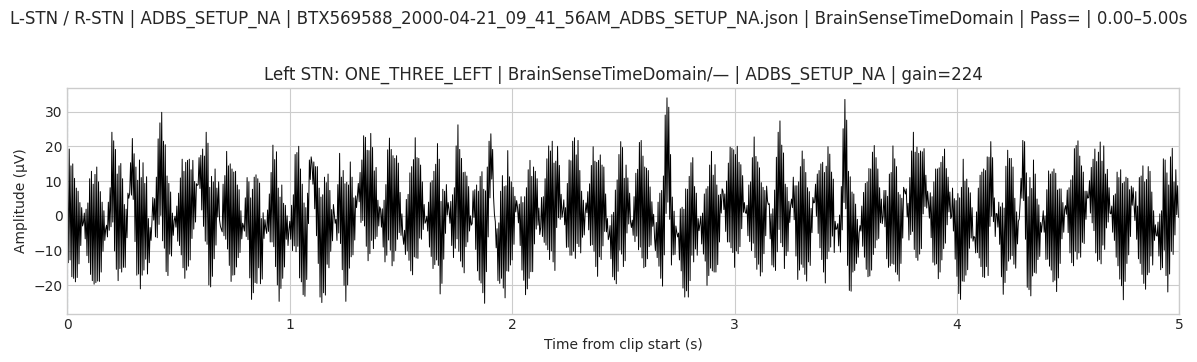

In [12]:
EXPORT_SEGMENT_INDEX = 19
EXPORT_START_SEC = 0.0
EXPORT_WINDOW_SEC = 5.0

if not bilateral_segments:
    print('No bilateral segments to export.')
elif not 0 <= EXPORT_SEGMENT_INDEX < len(bilateral_segments):
    print(
        f'EXPORT_SEGMENT_INDEX={EXPORT_SEGMENT_INDEX} is out of range '
        f'(valid 0..{len(bilateral_segments) - 1}).'
    )
else:
    seg = bilateral_segments[EXPORT_SEGMENT_INDEX]
    plot_bilateral_segment(seg, EXPORT_START_SEC, EXPORT_WINDOW_SEC, seconds_axis=True)
    plt.show()

## Notes

- **Chronic home beta** (`LFPTrendLogs` on visit files) is a different stream — not comparable to raw waveforms here. See the visit LFP section for beta center Hz + channel linkage.
- **Beta frequency** for chronic `LFP` values: `ProgramSettings.SensingChannel[].SensingSetup.FrequencyInHertz` (e.g. 23.44 Hz). In-clinic `ChannelSignalResult.SignalFrequencies` / PSD is a separate spectral snapshot; `PeakFrequencies` is often empty in exports.
- `CalibrationTests` with `Pass=ZERO_TWO` are the impedance/calibration runs for the 0–2 bipolar; they should match `SensingElectrodeConfigDef.ZERO_AND_TWO`.
- `SenseChannelTests` / `BrainSenseTimeDomain` use the same `Channel` naming (`ZERO_TWO_LEFT`, etc.).
- **ADBS_SETUP** JSON can be large (~30 MB); this notebook only opens a few early files per patient.
- Adapt group / hemisphere are **auto-detected** from the latest `ADBS_SETUP` (or baseline/eval) JSON; see the `sensing` table.